### **🚢 Project: Titanic Survival Analysis**

In [15]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset('titanic')
import matplotlib.pyplot as plt

## **Data Cleaning**

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df["age"] = df["age"].fillna(df["age"].mean())
df.drop(columns=['deck'], inplace=True)

In [6]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [7]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## **Visualizations**

### **Question 1 — How many people survived vs died?**

In [8]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

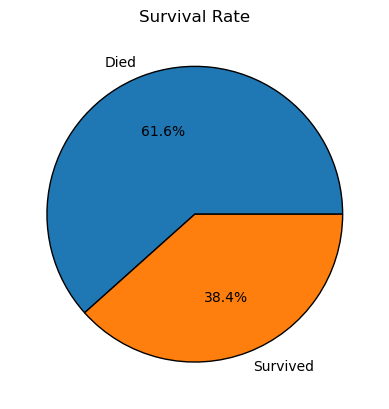

In [9]:
labels = ["Died", "Survived"]
vals = [549, 342]
plt.pie(vals, labels=labels, autopct='%1.1f%%',wedgeprops = {'edgecolor': 'black' , 'linewidth':1 , 'linestyle':'-'})
plt.title("Survival Rate")
plt.show()

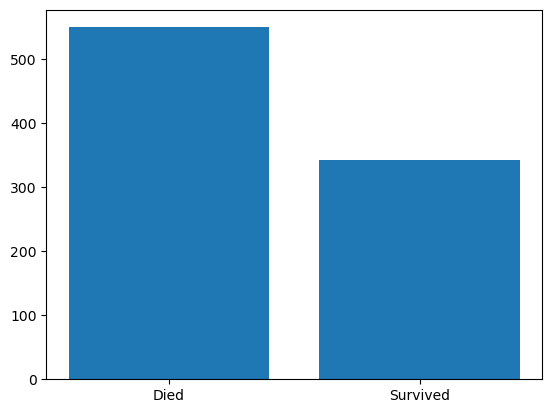

In [10]:
counts = df['survived'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks([0, 1], ["Died", "Survived"])
plt.show()

### **Question 2 — Which passenger class had the best survival rate?**

In [11]:
grouped = df.groupby("class")["survived"].mean()

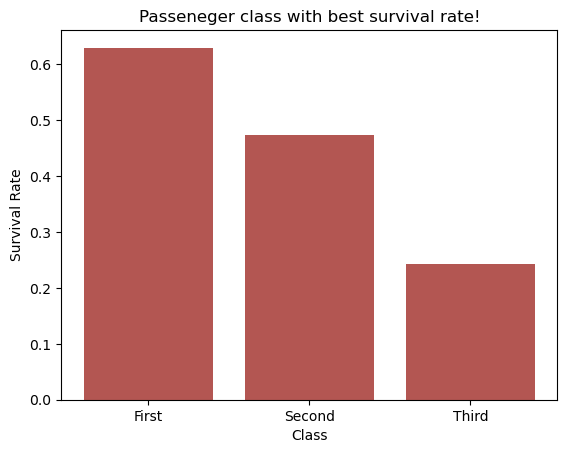

In [12]:
plt.bar(grouped.index , grouped.values , color = "#B35652")
plt.title("Passeneger class with best survival rate!")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

### **Question 3 — Did gender affect survival?**

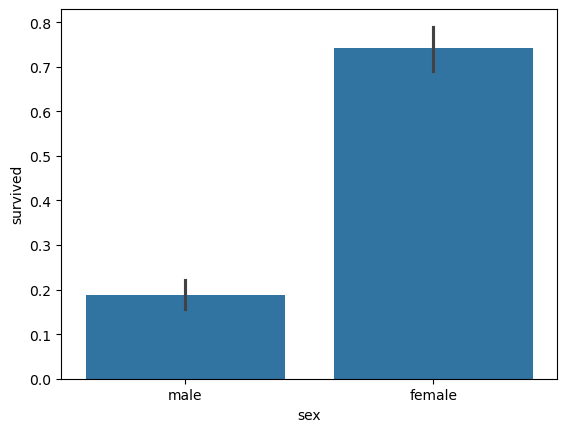

In [13]:
sns.barplot(data = df , x = "sex" , y = "survived")
plt.show()

### **Question 4 — Which age group survived the most?**

In [16]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Middle Age", "Senior"]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [18]:
df.groupby("age_group")["survived"].mean()

age_group
Child          0.579710
Teen           0.428571
Young Adult    0.382682
Middle Age     0.400000
Senior         0.227273
Name: survived, dtype: float64

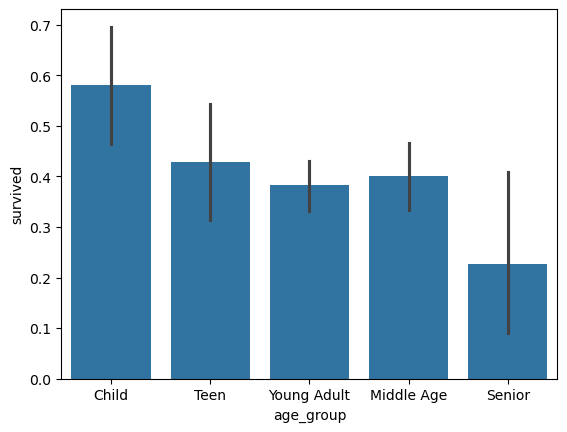

In [21]:
sns.barplot(data = df , x = "age_group" , y = "survived")
plt.show()

### **Question 5 — Did paying more fare increase survival chances?**

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
bins = [0, 50, 100, 200, 512]
labels = ["Low", "Medium", "High", "Very High"]
df['fare_group'] = pd.cut(df['fare'], bins=bins, labels=labels)

In [25]:
df.groupby("fare_group")["survived"].mean()

fare_group
Low          0.324022
Medium       0.654206
High         0.757576
Very High    0.647059
Name: survived, dtype: float64

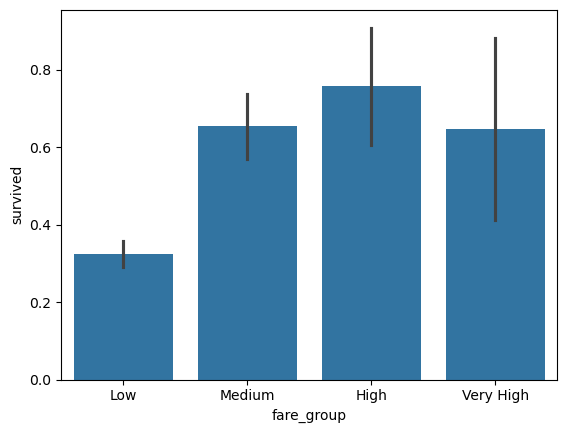

In [27]:
sns.barplot(data = df , x = "fare_group" , y = "survived")
plt.show()